# I.Master ( Dữ liệu tham chiếu )

## Product

In [2]:
import pandas as pd

# Load data
df = pd.read_csv("data/products.csv")

print("🔹 1. Shape (rows, columns):")
print(df.shape)

print("\n🔹 2. Data types:")
print(df.dtypes)

print("\n🔹 3. Missing values:")
print(df.isnull().sum())

print("\n🔹 4. Duplicate rows:")
print(df.duplicated().sum())

print("\n🔹 5. Basic statistics (numeric):")
print(df.describe())

print("\n🔹 6. Unique values per column:")
print(df.nunique())

print("\n🔹 7. Category distribution:")
print(df['category'].value_counts())

print("\n🔹 8. Segment distribution:")
print(df['segment'].value_counts())

print("\n🔹 9. Size distribution:")
print(df['size'].value_counts())

print("\n🔹 10. Color distribution (top 10):")
print(df['color'].value_counts().head(10))

print("\n🔹 11. Price vs COGS check:")
print("Min price:", df['price'].min())
print("Min cogs:", df['cogs'].min())
print("Any invalid rows (price <= cogs):", (df['price'] <= df['cogs']).sum())

🔹 1. Shape (rows, columns):
(2412, 8)

🔹 2. Data types:
product_id        int64
product_name     object
category         object
segment          object
size             object
color            object
price           float64
cogs            float64
dtype: object

🔹 3. Missing values:
product_id      0
product_name    0
category        0
segment         0
size            0
color           0
price           0
cogs            0
dtype: int64

🔹 4. Duplicate rows:
0

🔹 5. Basic statistics (numeric):
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   7720.513784   5864.916462
max    2412.000000  40950.000000  38902.500000

🔹 6. Unique values per column:
product_id      2412
product_name    2172
cate

## Customer

In [3]:
# 👤 EDA tổng quan cho customers.csv

import pandas as pd

# Load data
df = pd.read_csv("data/customers.csv", parse_dates=['signup_date'])

print("🔹 1. Shape (rows, columns):")
print(df.shape)

print("\n🔹 2. Data types:")
print(df.dtypes)

print("\n🔹 3. Missing values:")
print(df.isnull().sum())

print("\n🔹 4. Duplicate customer_id:")
print(df['customer_id'].duplicated().sum())

print("\n🔹 5. Unique values per column:")
print(df.nunique())

# =========================
# 👤 CUSTOMER PROFILE
# =========================
print("\n🔹 6. Gender distribution:")
print(df['gender'].value_counts(dropna=False))

print("\n🔹 7. Age group distribution:")
print(df['age_group'].value_counts(dropna=False))

print("\n🔹 8. Acquisition channel distribution:")
print(df['acquisition_channel'].value_counts(dropna=False))

# =========================
# 📍 LOCATION
# =========================
print("\n🔹 9. Top 10 cities:")
print(df['city'].value_counts().head(10))

print("\n🔹 10. Zip coverage:")
print("Unique ZIP codes:", df['zip'].nunique())

# =========================
# 📅 SIGNUP ANALYSIS
# =========================
print("\n🔹 11. Signup date range:")
print("Min:", df['signup_date'].min())
print("Max:", df['signup_date'].max())

# Tạo thêm cột time-based
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.to_period('M')

print("\n🔹 12. Customers by year:")
print(df['signup_year'].value_counts().sort_index())

print("\n🔹 13. Customers by month (top 10):")
print(df['signup_month'].value_counts().sort_index().tail(10))

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 14. Rows missing ALL demographic info (gender + age_group):")
print(df[(df['gender'].isna()) & (df['age_group'].isna())].shape[0])

🔹 1. Shape (rows, columns):
(121930, 7)

🔹 2. Data types:
customer_id                     int64
zip                             int64
city                           object
signup_date            datetime64[ns]
gender                         object
age_group                      object
acquisition_channel            object
dtype: object

🔹 3. Missing values:
customer_id            0
zip                    0
city                   0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

🔹 4. Duplicate customer_id:
0

🔹 5. Unique values per column:
customer_id            121930
zip                     31491
city                       42
signup_date              3941
gender                      3
age_group                   5
acquisition_channel         6
dtype: int64

🔹 6. Gender distribution:
gender
Female        59640
Male          57457
Non-binary     4833
Name: count, dtype: int64

🔹 7. Age group distribution:
age_group
25-34 

## Promotion

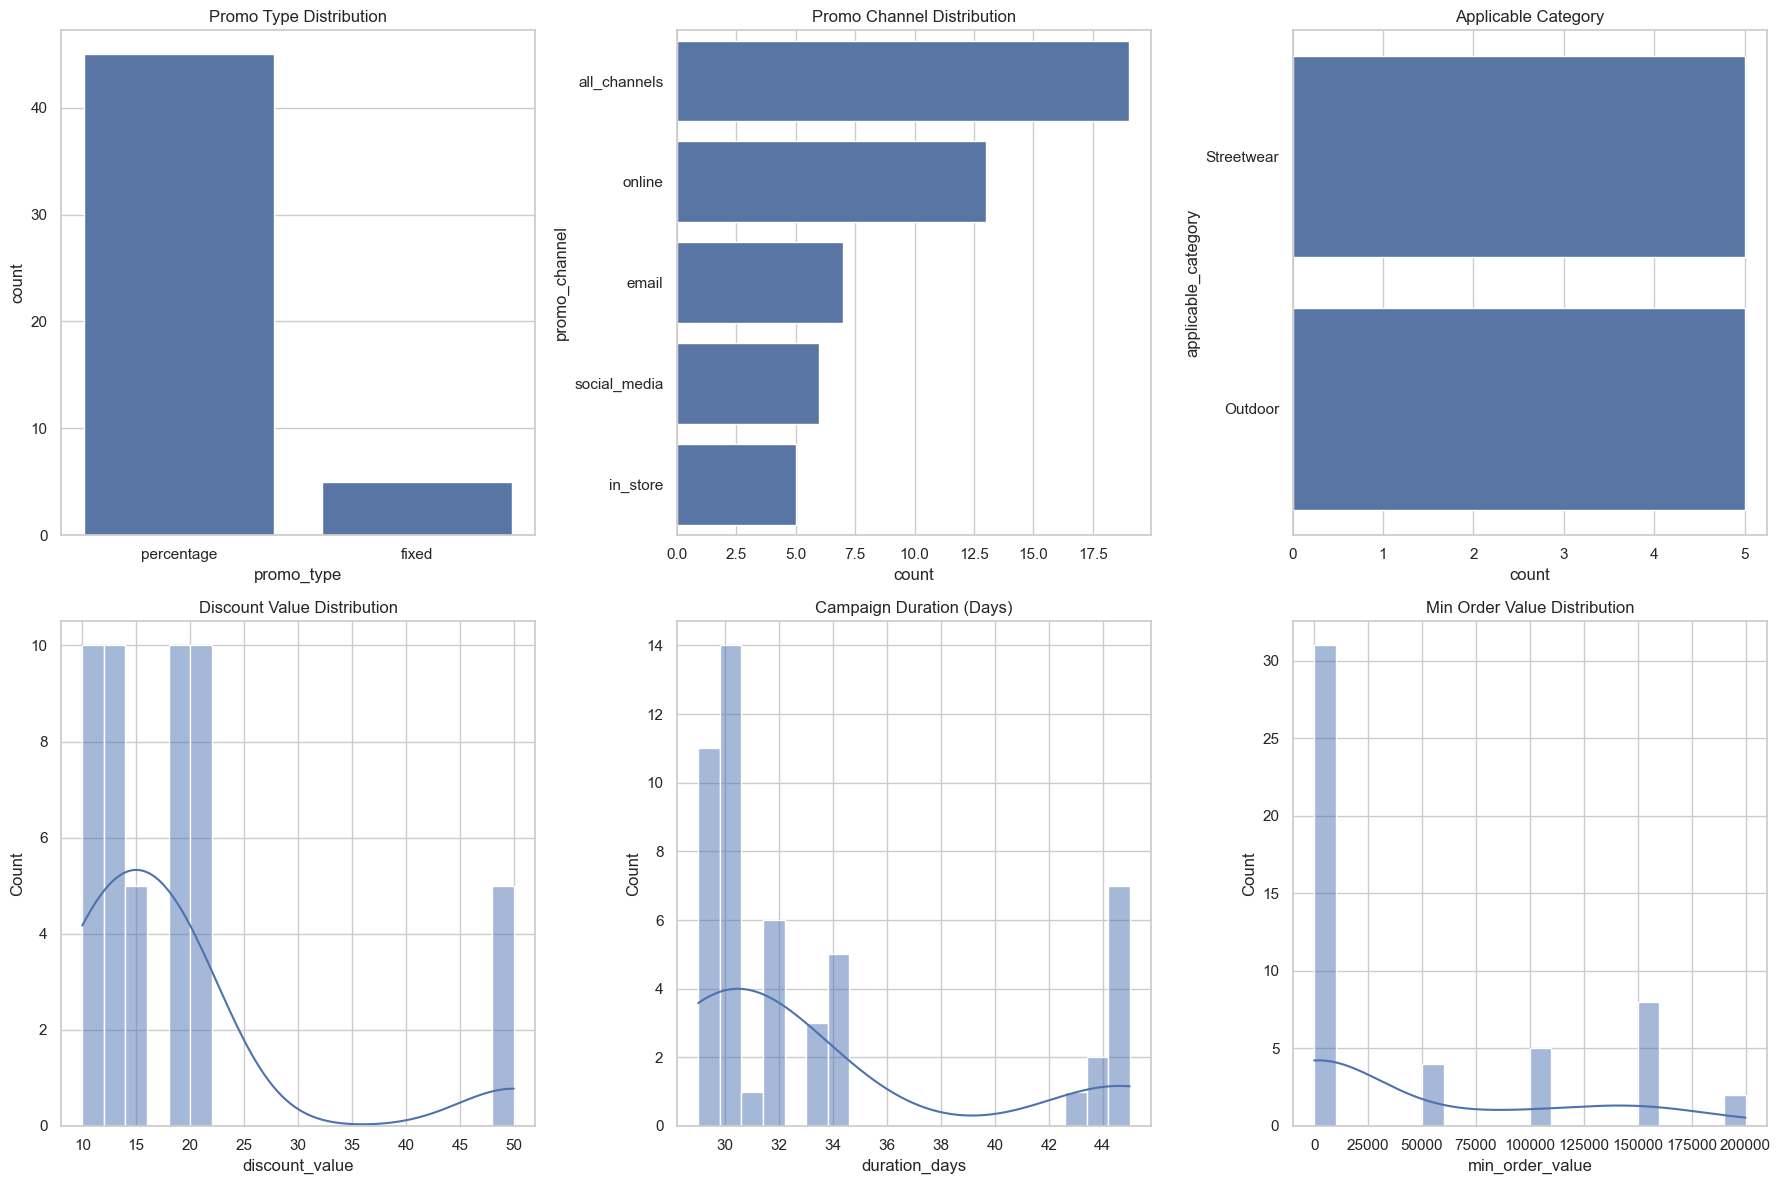

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# style
sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/promotions.csv", parse_dates=['start_date', 'end_date'])

# 📊 FEATURE ENGINEERING
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days

# 🎨 VISUALIZATION
plt.figure(figsize=(18, 12))

# 1. Promo type distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='promo_type')
plt.title("Promo Type Distribution")

# 2. Promo channel
plt.subplot(2, 3, 2)
sns.countplot(data=df, y='promo_channel', order=df['promo_channel'].value_counts().index)
plt.title("Promo Channel Distribution")

# 3. Applicable category
plt.subplot(2, 3, 3)
sns.countplot(data=df, y='applicable_category', order=df['applicable_category'].value_counts().index)
plt.title("Applicable Category")

# 4. Discount distribution
plt.subplot(2, 3, 4)
sns.histplot(df['discount_value'], bins=20, kde=True)
plt.title("Discount Value Distribution")

# 5. Campaign duration
plt.subplot(2, 3, 5)
sns.histplot(df['duration_days'], bins=20, kde=True)
plt.title("Campaign Duration (Days)")

# 6. Min order value
plt.subplot(2, 3, 6)
sns.histplot(df['min_order_value'].dropna(), bins=20, kde=True)
plt.title("Min Order Value Distribution")

plt.tight_layout()
plt.show()

## Geography

🔹 Shape: (39948, 4)

🔹 Data types:
 zip          int64
city        object
region      object
district    object
dtype: object

🔹 Missing values:
 zip         0
city        0
region      0
district    0
dtype: int64

🔹 Duplicate ZIP: 0

🔹 Unique values:
 zip         39948
city           42
region          3
district       39
dtype: int64


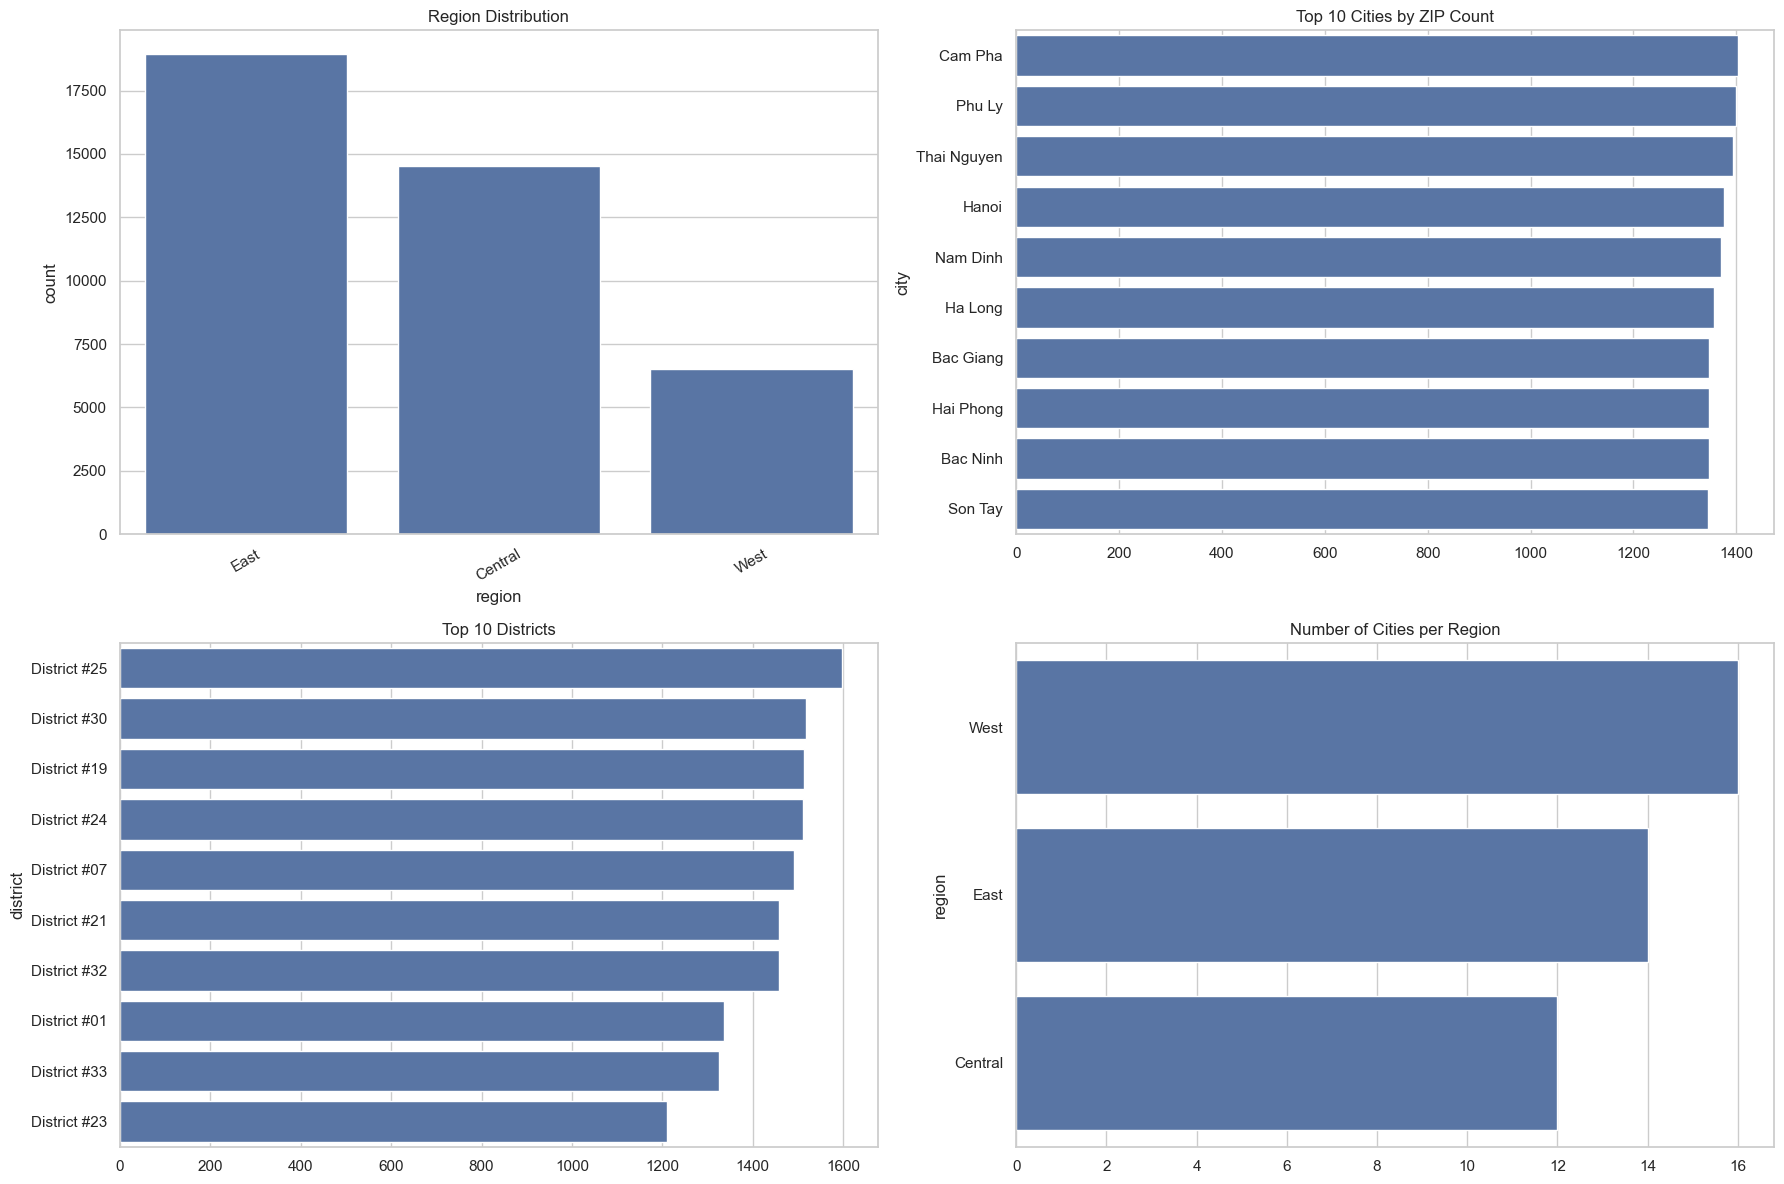

In [3]:
# 🌍 EDA + Visualization cho geography.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/geography.csv")

# =========================
# 📊 OVERVIEW
# =========================
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate ZIP:", df['zip'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# =========================
# 🎨 VISUALIZATION
# =========================

plt.figure(figsize=(18, 12))

# 1. Region distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title("Region Distribution")
plt.xticks(rotation=30)

# 2. Top cities
plt.subplot(2, 2, 2)
top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by ZIP Count")

# 3. Top districts
plt.subplot(2, 2, 3)
top_districts = df['district'].value_counts().head(10)
sns.barplot(x=top_districts.values, y=top_districts.index)
plt.title("Top 10 Districts")

# 4. City per region (cross view)
plt.subplot(2, 2, 4)
region_city = df.groupby('region')['city'].nunique().sort_values(ascending=False)
sns.barplot(x=region_city.values, y=region_city.index)
plt.title("Number of Cities per Region")

plt.tight_layout()
plt.show()

# II.Transaction ( Giao dịch )

## Orders

🔹 Shape: (646945, 8)

🔹 Data types:
 order_id                   int64
order_date        datetime64[ns]
customer_id                int64
zip                        int64
order_status              object
payment_method            object
device_type               object
order_source              object
dtype: object

🔹 Missing values:
 order_id          0
order_date        0
customer_id       0
zip               0
order_status      0
payment_method    0
device_type       0
order_source      0
dtype: int64

🔹 Duplicate order_id: 0

🔹 Unique values:
 order_id          646945
order_date          3833
customer_id        90246
zip                29932
order_status           6
payment_method         5
device_type            3
order_source           6
dtype: int64


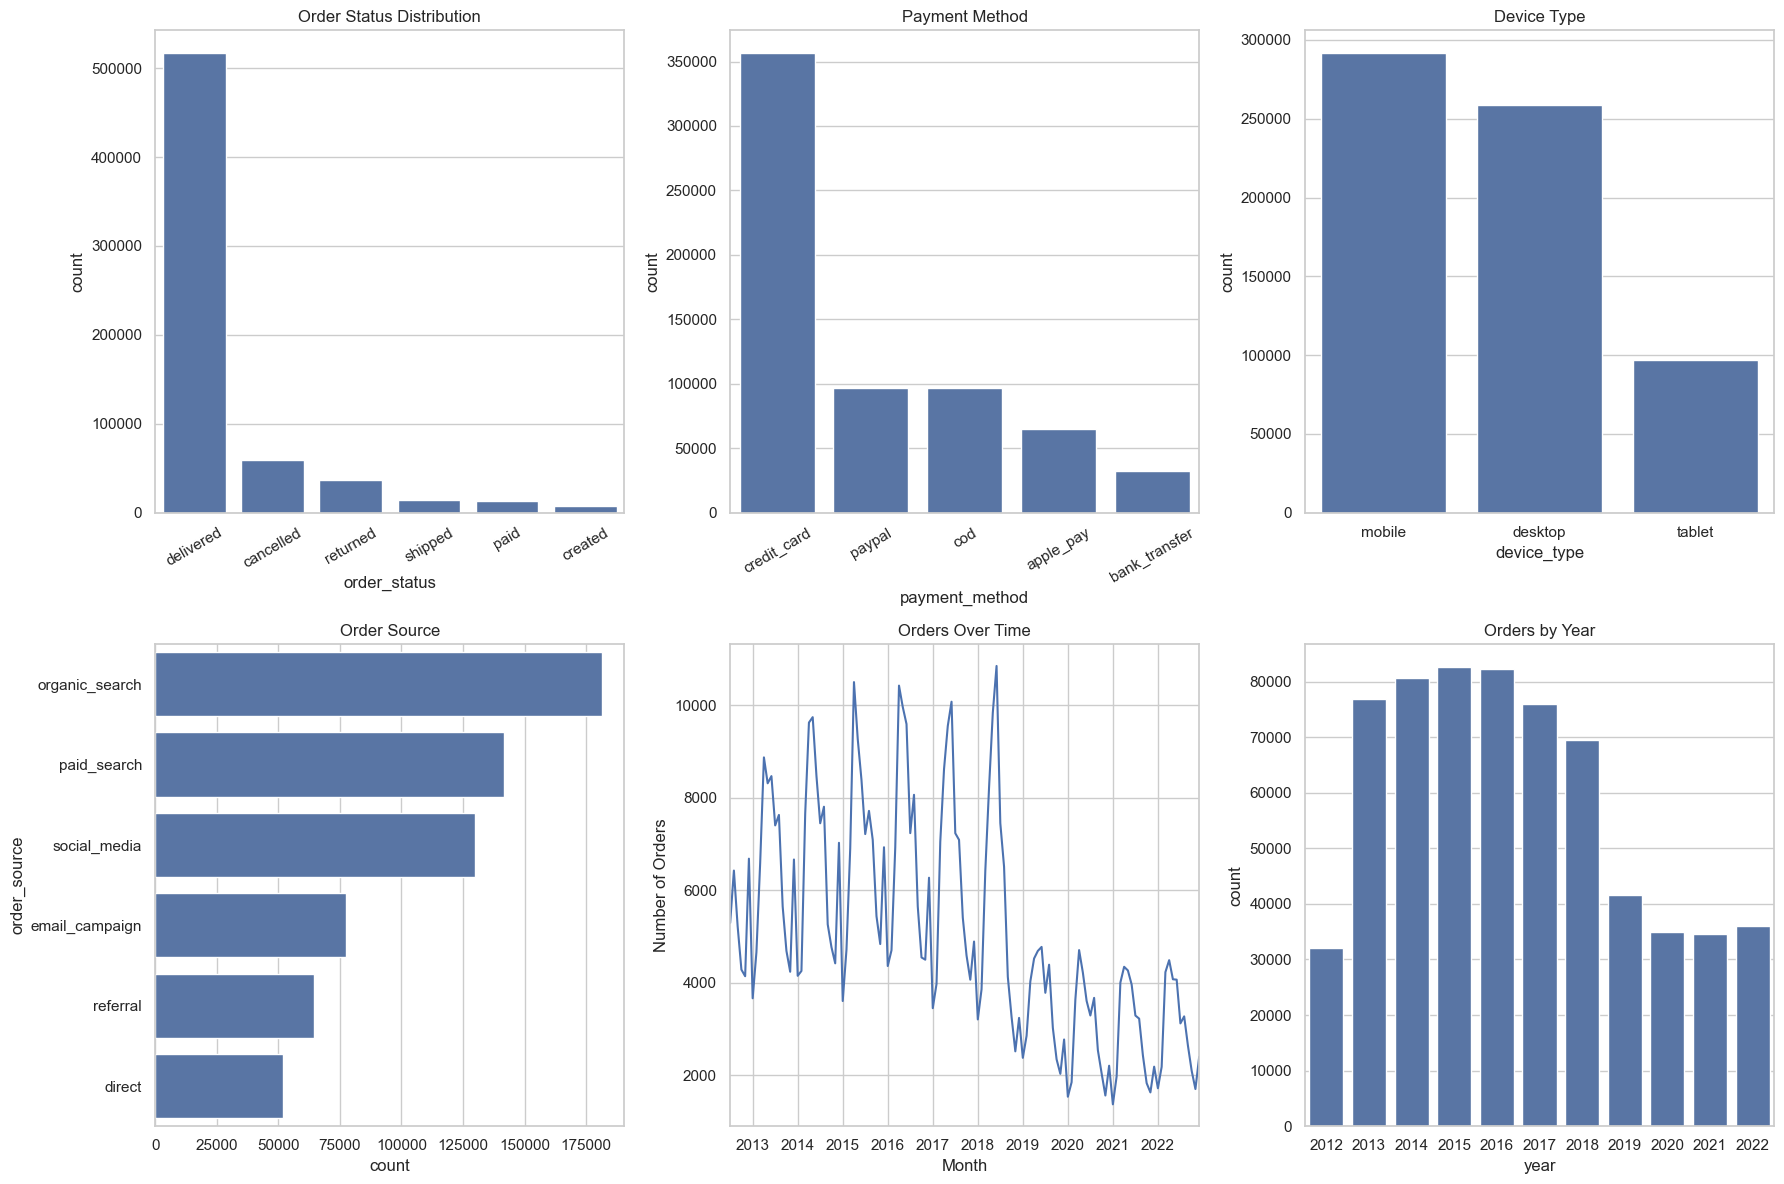

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/orders.csv", parse_dates=['order_date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate order_id:", df['order_id'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.to_period('M')

# 🎨 VISUALIZATION
plt.figure(figsize=(18, 12))

# 1. Order status distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='order_status', order=df['order_status'].value_counts().index)
plt.title("Order Status Distribution")
plt.xticks(rotation=30)

# 2. Payment method
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index)
plt.title("Payment Method")
plt.xticks(rotation=30)

# 3. Device type
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='device_type', order=df['device_type'].value_counts().index)
plt.title("Device Type")

# 4. Order source (marketing channel)
plt.subplot(2, 3, 4)
sns.countplot(data=df, y='order_source', order=df['order_source'].value_counts().index)
plt.title("Order Source")

# 5. Orders over time (monthly)
plt.subplot(2, 3, 5)
orders_by_month = df.groupby('month').size()
orders_by_month.plot()
plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

# 6. Orders by year
plt.subplot(2, 3, 6)
sns.countplot(data=df, x='year')
plt.title("Orders by Year")

plt.tight_layout()
plt.show()

## Order_items

C:\Users\nguye\AppData\Local\Temp\ipykernel_23736\2191287667.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/order_items.csv")


🔹 Shape: (714669, 7)

🔹 Data types:
 order_id             int64
product_id           int64
quantity             int64
unit_price         float64
discount_amount    float64
promo_id            object
promo_id_2          object
dtype: object

🔹 Missing values:
 order_id                0
product_id              0
quantity                0
unit_price              0
discount_amount         0
promo_id           438353
promo_id_2         714463
dtype: int64

🔹 Duplicate rows: 0

🔹 Unique values:
 order_id           646945
product_id           1598
quantity                8
unit_price         501330
discount_amount    204449
promo_id               50
promo_id_2              2
dtype: int64


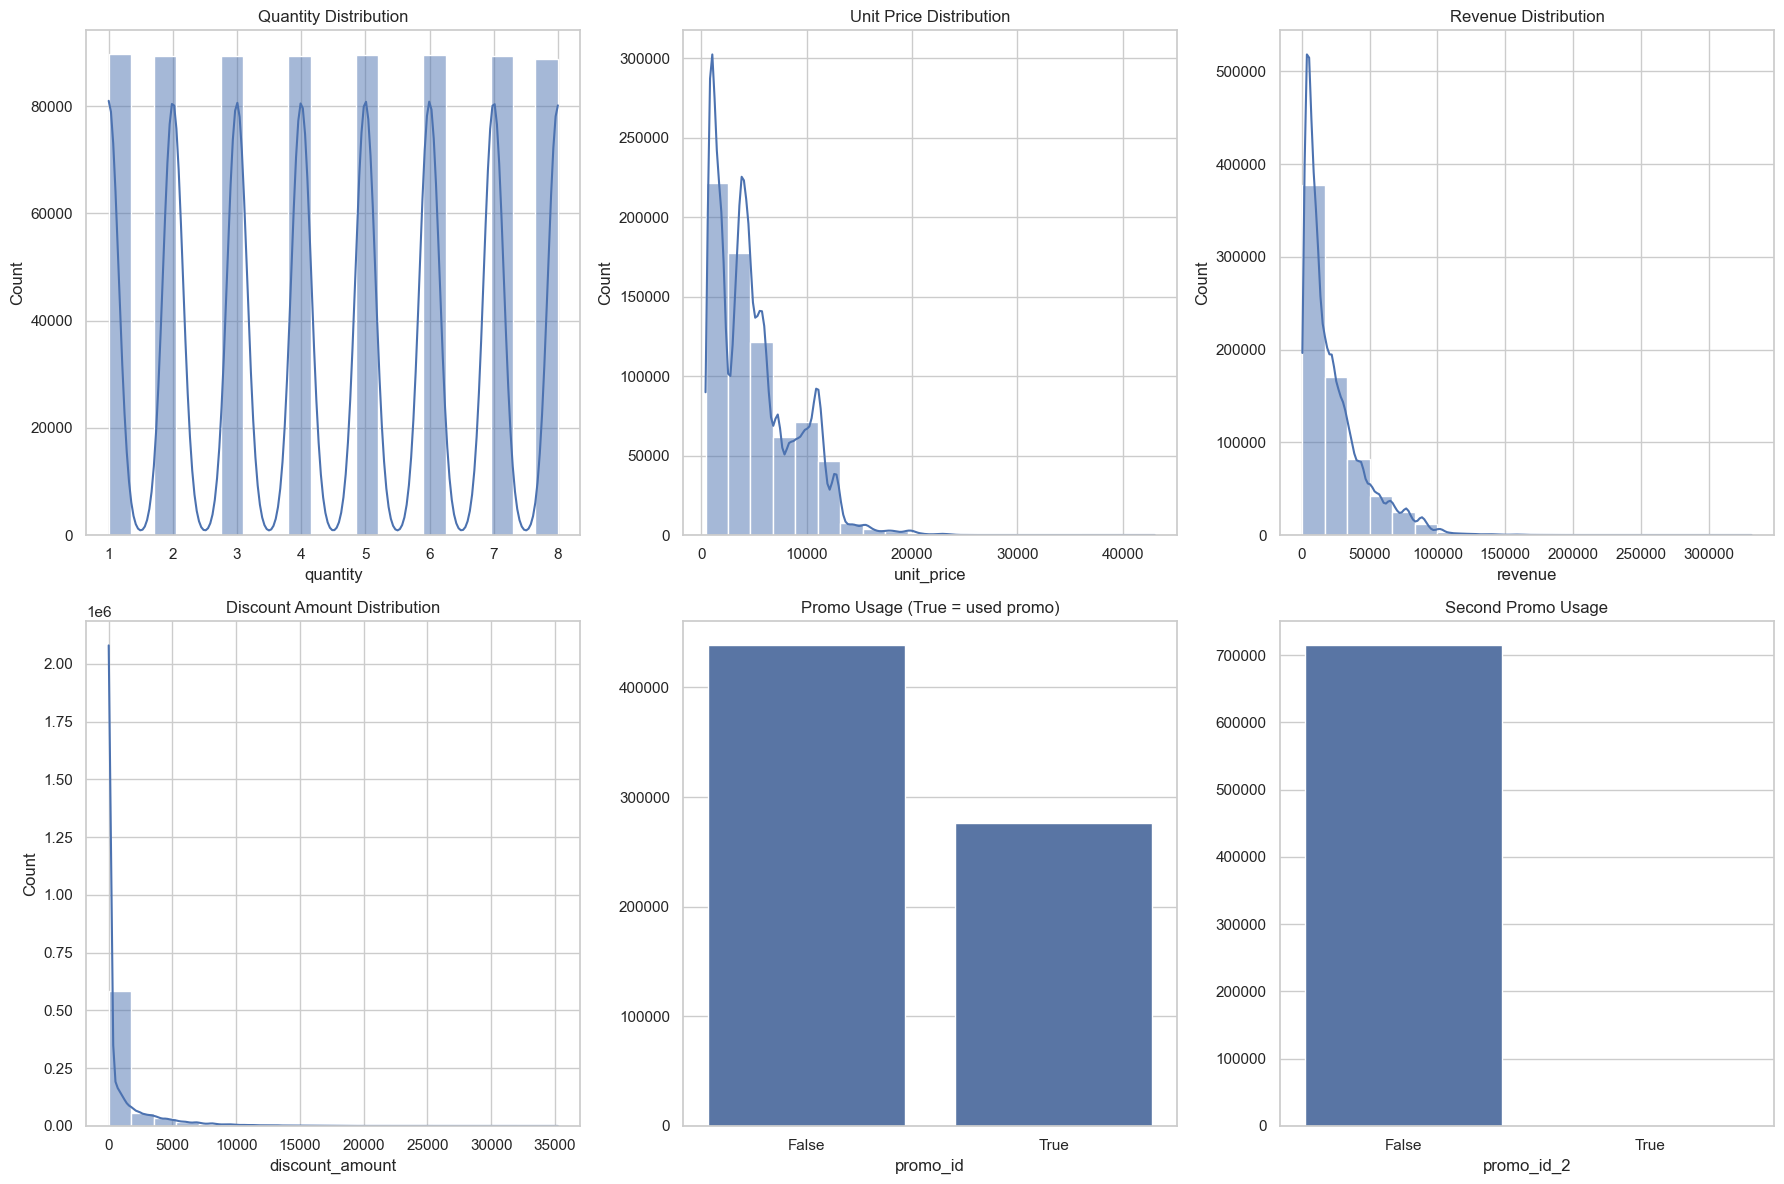


🔹 Invalid quantity (<=0): 0
🔹 Invalid price (<0): 0
🔹 Invalid discount (<0): 0
🔹 Division by zero risk (quantity=0): 0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/order_items.csv")


# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate rows:", df.duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 💰 FEATURE ENGINEERING
df['revenue'] = df['quantity'] * df['unit_price']
df['avg_discount_per_unit'] = df['discount_amount'] / df['quantity']

# 🎨 VISUALIZATION
plt.figure(figsize=(18, 12))

# 1. Quantity distribution
plt.subplot(2, 3, 1)
sns.histplot(df['quantity'], bins=20, kde=True)
plt.title("Quantity Distribution")

# 2. Unit price distribution
plt.subplot(2, 3, 2)
sns.histplot(df['unit_price'], bins=20, kde=True)
plt.title("Unit Price Distribution")

# 3. Revenue distribution
plt.subplot(2, 3, 3)
sns.histplot(df['revenue'], bins=20, kde=True)
plt.title("Revenue Distribution")

# 4. Discount distribution
plt.subplot(2, 3, 4)
sns.histplot(df['discount_amount'], bins=20, kde=True)
plt.title("Discount Amount Distribution")

# 5. Promo usage
plt.subplot(2, 3, 5)
promo_usage = df['promo_id'].notna().value_counts()
sns.barplot(x=promo_usage.index.astype(str), y=promo_usage.values)
plt.title("Promo Usage (True = used promo)")

# 6. Double promo usage
plt.subplot(2, 3, 6)
double_promo = df['promo_id_2'].notna().value_counts()
sns.barplot(x=double_promo.index.astype(str), y=double_promo.values)
plt.title("Second Promo Usage")

plt.tight_layout()
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Invalid quantity (<=0):", (df['quantity'] <= 0).sum())
print("🔹 Invalid price (<0):", (df['unit_price'] < 0).sum())
print("🔹 Invalid discount (<0):", (df['discount_amount'] < 0).sum())
print("🔹 Division by zero risk (quantity=0):", (df['quantity'] == 0).sum())

## Payments

🔹 Shape: (646945, 4)

🔹 Data types:
 order_id            int64
payment_method     object
payment_value     float64
installments        int64
dtype: object

🔹 Missing values:
 order_id          0
payment_method    0
payment_value     0
installments      0
dtype: int64

🔹 Duplicate order_id (should be 0 for 1:1): 0

🔹 Unique values:
 order_id          646945
payment_method         5
payment_value     595420
installments           5
dtype: int64


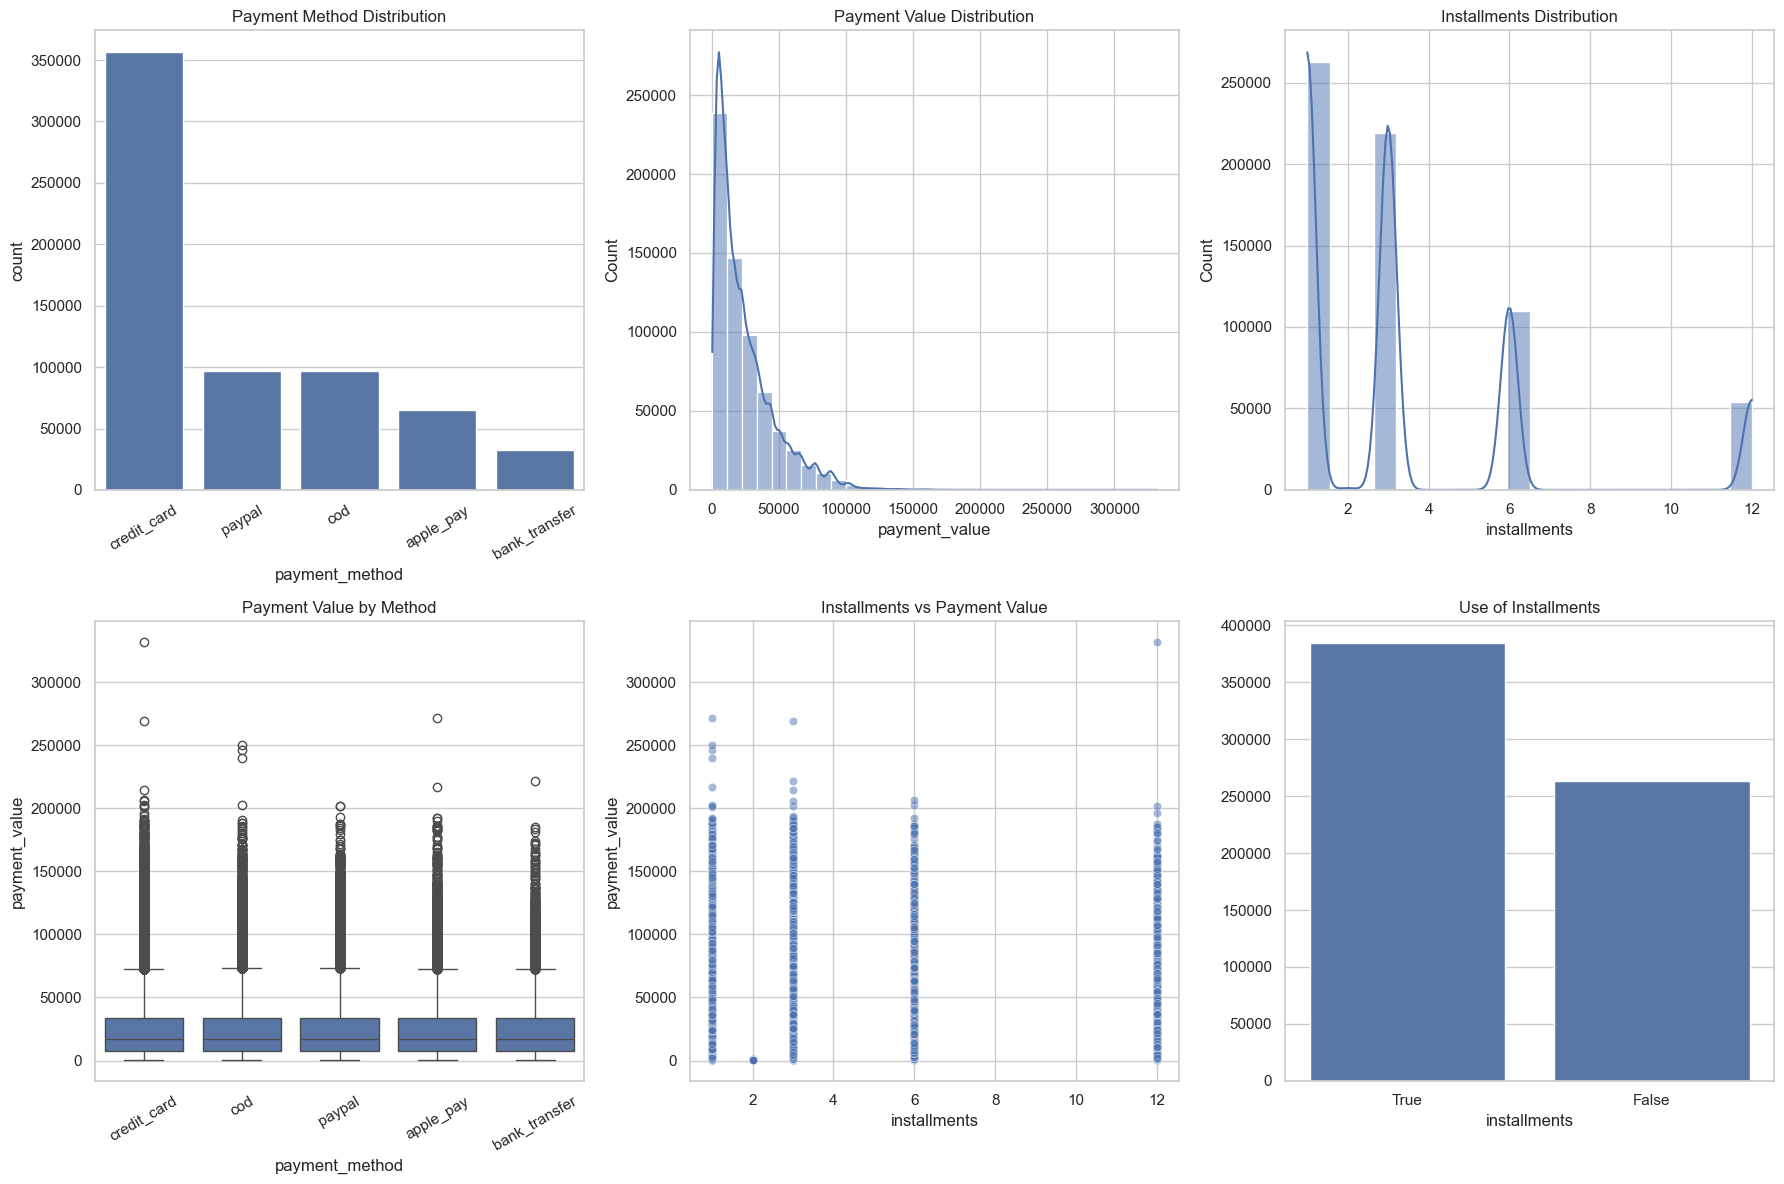


🔹 Invalid payment_value (<0): 0
🔹 Invalid installments (<0): 0
🔹 Zero payment orders: 0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/payments.csv")

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate order_id (should be 0 for 1:1):", df['order_id'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 🎨 VISUALIZATION
plt.figure(figsize=(18, 12))

# 1. Payment method distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='payment_method', order=df['payment_method'].value_counts().index)
plt.title("Payment Method Distribution")
plt.xticks(rotation=30)

# 2. Payment value distribution
plt.subplot(2, 3, 2)
sns.histplot(df['payment_value'], bins=30, kde=True)
plt.title("Payment Value Distribution")

# 3. Installments distribution
plt.subplot(2, 3, 3)
sns.histplot(df['installments'], bins=20, kde=True)
plt.title("Installments Distribution")

# 4. Payment value by method
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='payment_method', y='payment_value')
plt.title("Payment Value by Method")
plt.xticks(rotation=30)

# 5. Installments vs payment value
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='installments', y='payment_value', alpha=0.5)
plt.title("Installments vs Payment Value")

# 6. Orders with installments > 1
plt.subplot(2, 3, 6)
install_flag = (df['installments'] > 1).value_counts()
sns.barplot(x=install_flag.index.astype(str), y=install_flag.values)
plt.title("Use of Installments")

plt.tight_layout()
plt.show()

# ⚠️ DATA QUALITY CHECK
print("\n🔹 Invalid payment_value (<0):", (df['payment_value'] < 0).sum())
print("🔹 Invalid installments (<0):", (df['installments'] < 0).sum())
print("🔹 Zero payment orders:", (df['payment_value'] == 0).sum())

## Shipments

🔹 Shape: (566067, 4)

🔹 Data types:
 order_id                  int64
ship_date        datetime64[ns]
delivery_date    datetime64[ns]
shipping_fee            float64
dtype: object

🔹 Missing values:
 order_id         0
ship_date        0
delivery_date    0
shipping_fee     0
dtype: int64

🔹 Duplicate order_id: 0

🔹 Unique values:
 order_id         566067
ship_date          3831
delivery_date      3831
shipping_fee       1856
dtype: int64


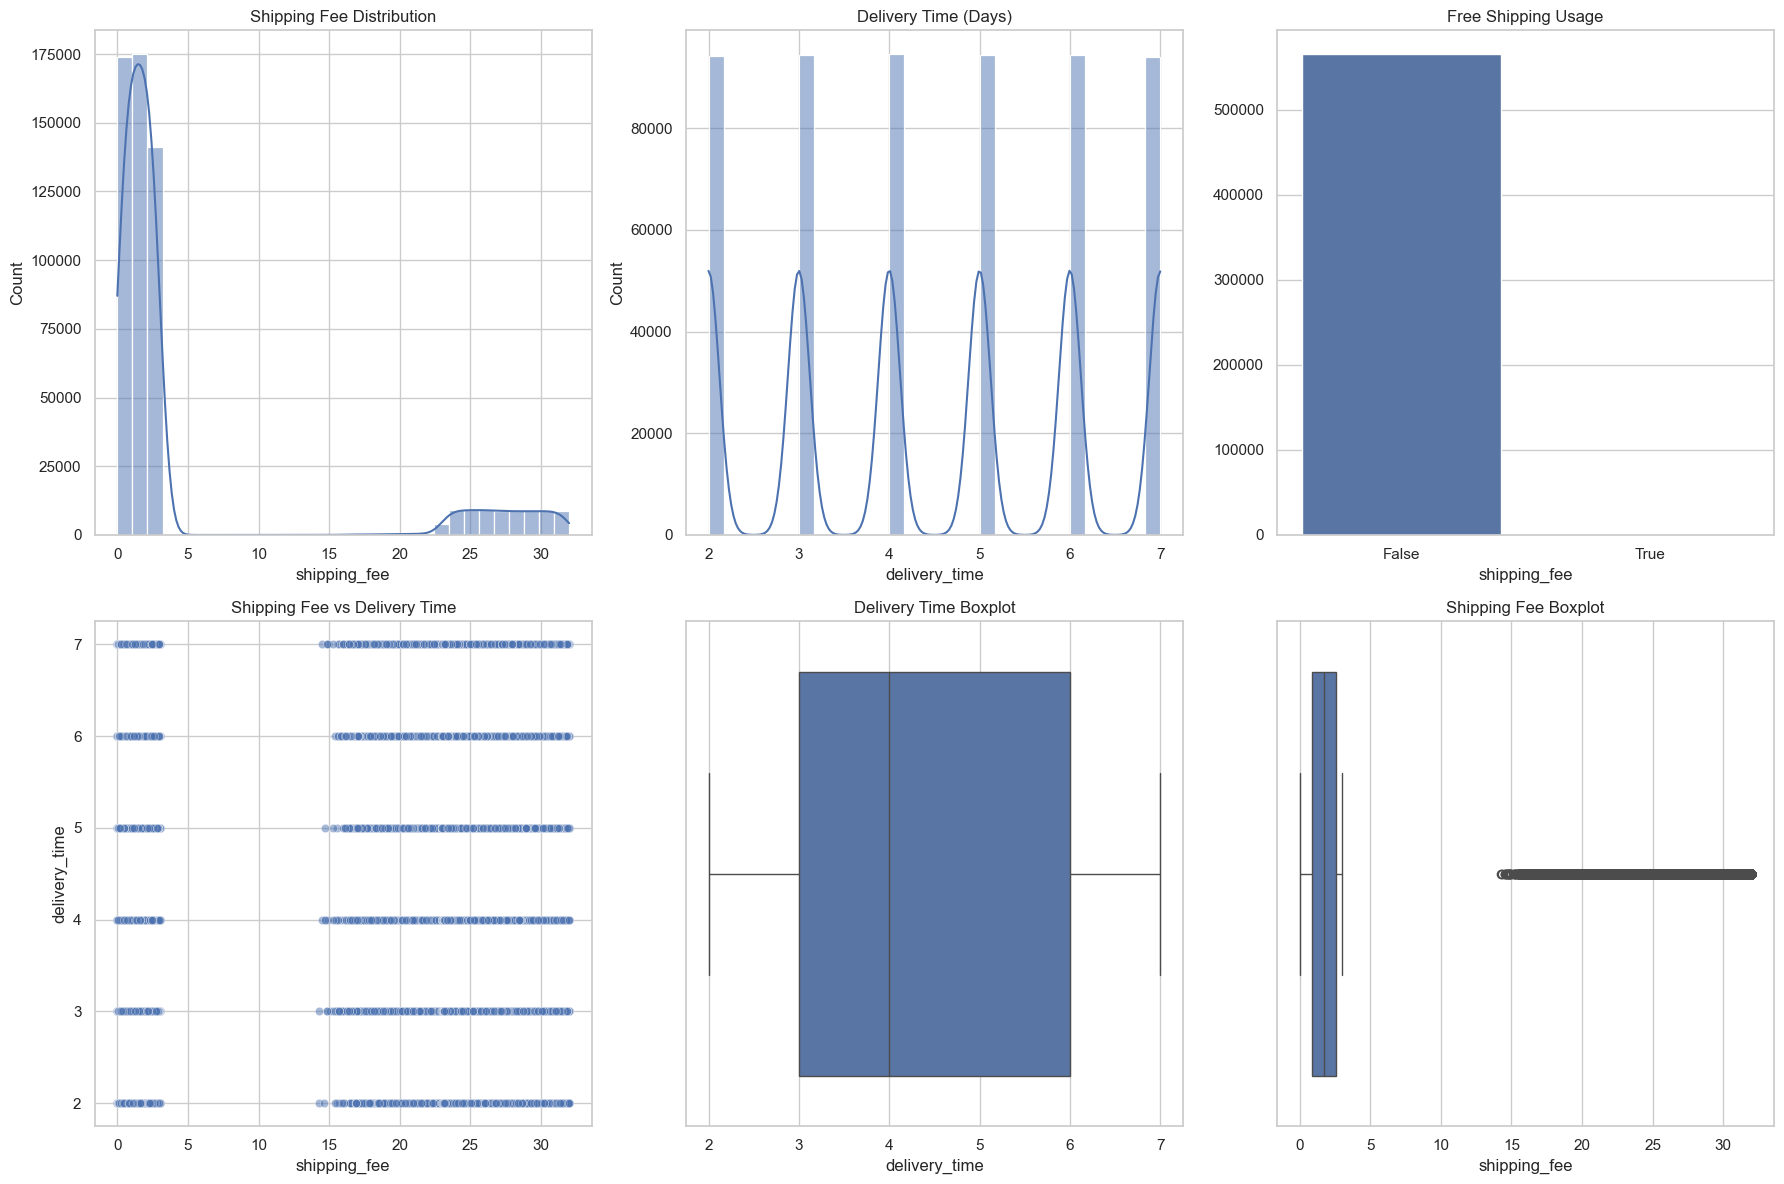


🔹 Invalid delivery_time (<0): 0
🔹 Missing ship_date: 0
🔹 Missing delivery_date: 0
🔹 Negative shipping_fee: 0


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/shipments.csv", parse_dates=['ship_date', 'delivery_date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate order_id:", df['order_id'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['delivery_time'] = (df['delivery_date'] - df['ship_date']).dt.days

# =========================
# Visualization
# =========================
plt.figure(figsize=(18, 12))

# 1. Shipping fee distribution
plt.subplot(2, 3, 1)
sns.histplot(df['shipping_fee'], bins=30, kde=True)
plt.title("Shipping Fee Distribution")

# 2. Delivery time distribution
plt.subplot(2, 3, 2)
sns.histplot(df['delivery_time'], bins=30, kde=True)
plt.title("Delivery Time (Days)")

# 3. Free shipping vs paid
plt.subplot(2, 3, 3)
free_ship = (df['shipping_fee'] == 0).value_counts()
sns.barplot(x=free_ship.index.astype(str), y=free_ship.values)
plt.title("Free Shipping Usage")

# 4. Shipping fee vs delivery time
plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='shipping_fee', y='delivery_time', alpha=0.5)
plt.title("Shipping Fee vs Delivery Time")

# 5. Delivery time boxplot
plt.subplot(2, 3, 5)
sns.boxplot(x=df['delivery_time'])
plt.title("Delivery Time Boxplot")

# 6. Shipping fee boxplot
plt.subplot(2, 3, 6)
sns.boxplot(x=df['shipping_fee'])
plt.title("Shipping Fee Boxplot")

plt.tight_layout()
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Invalid delivery_time (<0):", (df['delivery_time'] < 0).sum())
print("🔹 Missing ship_date:", df['ship_date'].isnull().sum())
print("🔹 Missing delivery_date:", df['delivery_date'].isnull().sum())
print("🔹 Negative shipping_fee:", (df['shipping_fee'] < 0).sum())

## Returns

🔹 Shape: (39939, 7)

🔹 Data types:
 return_id                  object
order_id                    int64
product_id                  int64
return_date        datetime64[ns]
return_reason              object
return_quantity             int64
refund_amount             float64
dtype: object

🔹 Missing values:
 return_id          0
order_id           0
product_id         0
return_date        0
return_reason      0
return_quantity    0
refund_amount      0
dtype: int64

🔹 Duplicate return_id: 0

🔹 Unique values:
 return_id          39939
order_id           36062
product_id          1286
return_date         3806
return_reason          5
return_quantity        8
refund_amount      39560
dtype: int64


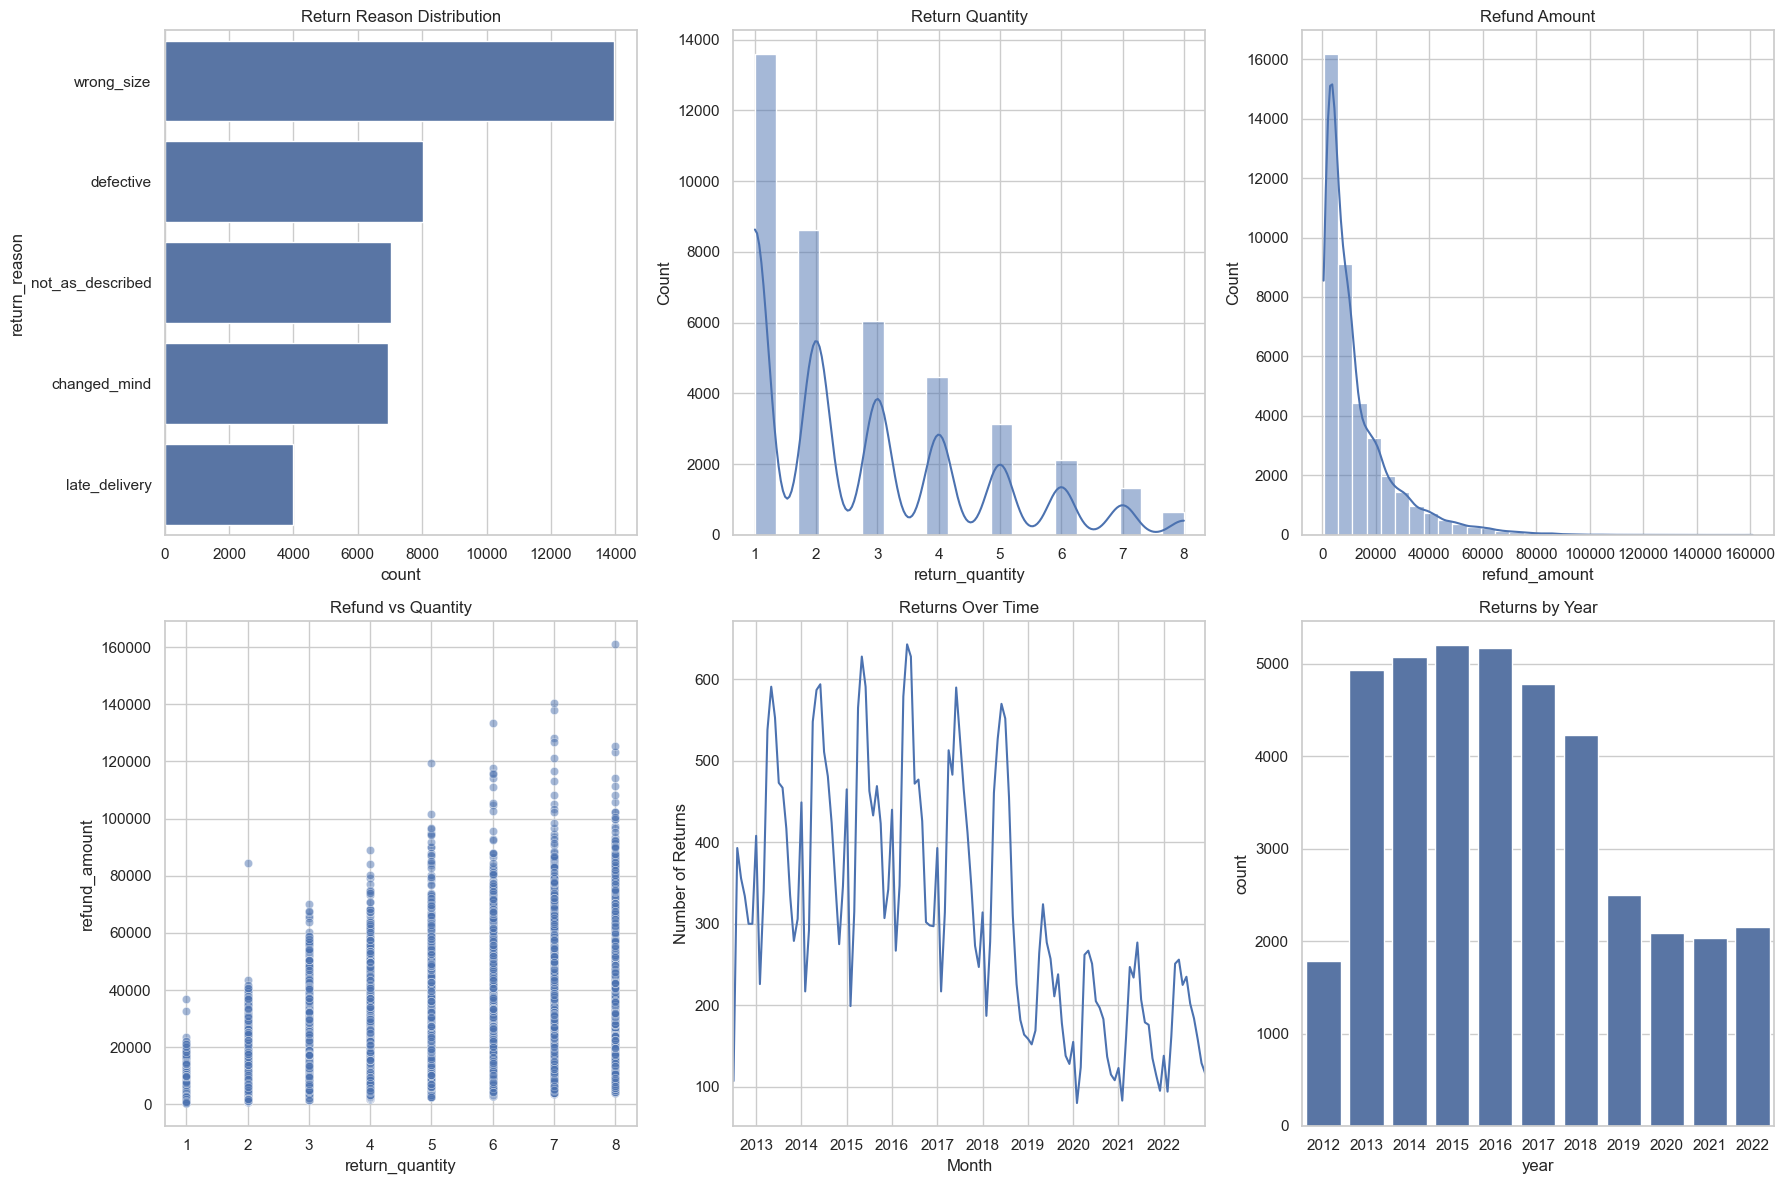


🔹 Invalid return_quantity (<=0): 0
🔹 Negative refund_amount: 0
🔹 Missing return_reason: 0


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/returns.csv", parse_dates=['return_date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate return_id:", df['return_id'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['year'] = df['return_date'].dt.year
df['month'] = df['return_date'].dt.to_period('M')

# Visualization
plt.figure(figsize=(18, 12))

# 1. Return reason distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, y='return_reason', order=df['return_reason'].value_counts().index)
plt.title("Return Reason Distribution")

# 2. Return quantity distribution
plt.subplot(2, 3, 2)
sns.histplot(df['return_quantity'], bins=20, kde=True)
plt.title("Return Quantity")

# 3. Refund amount distribution
plt.subplot(2, 3, 3)
sns.histplot(df['refund_amount'], bins=30, kde=True)
plt.title("Refund Amount")

# 4. Refund vs quantity
plt.subplot(2, 3, 4)
sns.scatterplot(data=df, x='return_quantity', y='refund_amount', alpha=0.5)
plt.title("Refund vs Quantity")

# 5. Returns over time
plt.subplot(2, 3, 5)
returns_by_month = df.groupby('month').size()
returns_by_month.plot()
plt.title("Returns Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Returns")

# 6. Returns by year
plt.subplot(2, 3, 6)
sns.countplot(data=df, x='year')
plt.title("Returns by Year")

plt.tight_layout()
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Invalid return_quantity (<=0):", (df['return_quantity'] <= 0).sum())
print("🔹 Negative refund_amount:", (df['refund_amount'] < 0).sum())
print("🔹 Missing return_reason:", df['return_reason'].isnull().sum())

## Reviews

🔹 Shape: (113551, 7)

🔹 Data types:
 review_id               object
order_id                 int64
product_id               int64
customer_id              int64
review_date     datetime64[ns]
rating                   int64
review_title            object
dtype: object

🔹 Missing values:
 review_id       0
order_id        0
product_id      0
customer_id     0
review_date     0
rating          0
review_title    0
dtype: int64

🔹 Duplicate review_id: 0

🔹 Unique values:
 review_id       113551
order_id        111369
product_id        1412
customer_id      48676
review_date       3825
rating               5
review_title        18
dtype: int64


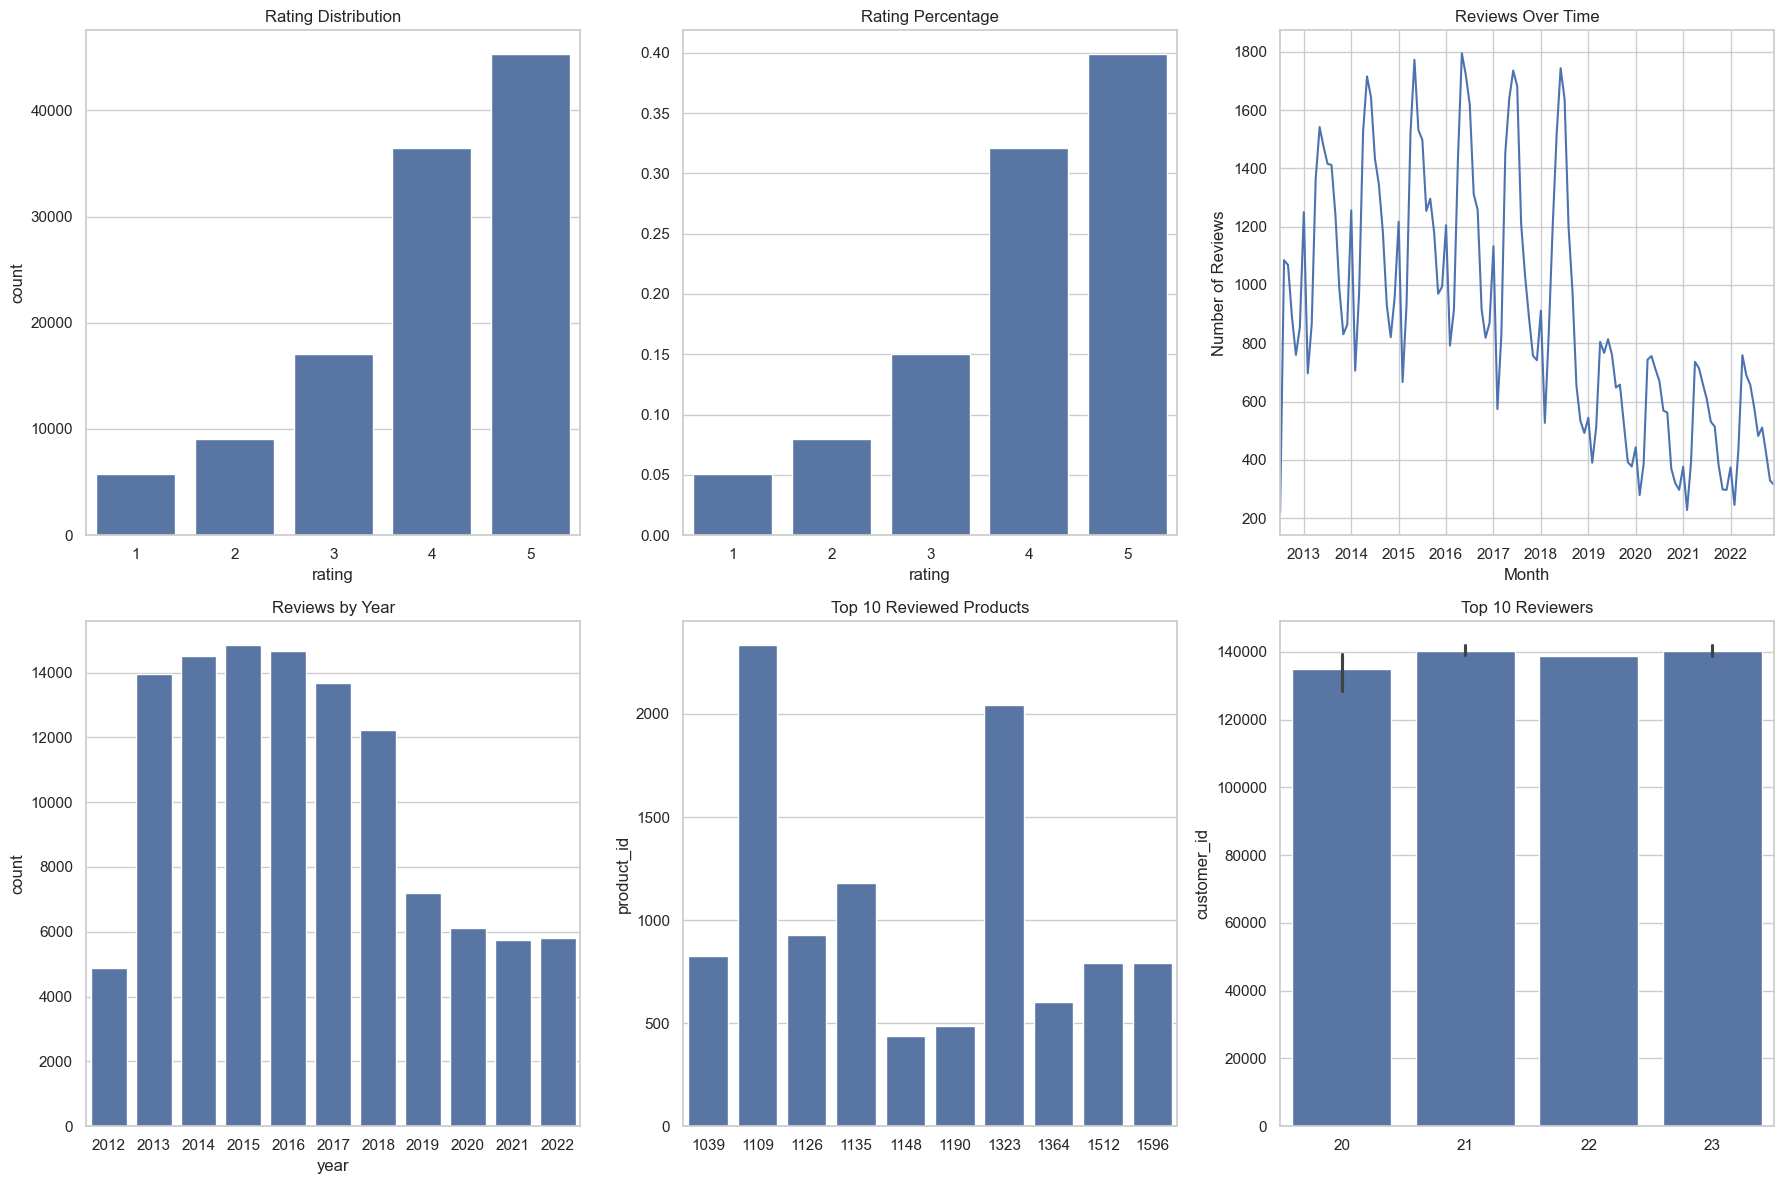


🔹 Invalid rating (<1 or >5): 0
🔹 Missing review_title: 0
🔹 Missing rating: 0


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/reviews.csv", parse_dates=['review_date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate review_id:", df['review_id'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['year'] = df['review_date'].dt.year
df['month'] = df['review_date'].dt.to_period('M')

# Visualization
plt.figure(figsize=(18, 12))

# 1. Rating distribution
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='rating', order=sorted(df['rating'].dropna().unique()))
plt.title("Rating Distribution")

# 2. Rating percentage
plt.subplot(2, 3, 2)
rating_pct = df['rating'].value_counts(normalize=True).sort_index()
sns.barplot(x=rating_pct.index, y=rating_pct.values)
plt.title("Rating Percentage")

# 3. Reviews over time
plt.subplot(2, 3, 3)
reviews_by_month = df.groupby('month').size()
reviews_by_month.plot()
plt.title("Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

# 4. Reviews by year
plt.subplot(2, 3, 4)
sns.countplot(data=df, x='year')
plt.title("Reviews by Year")

# 5. Top reviewed products
plt.subplot(2, 3, 5)
top_products = df['product_id'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Reviewed Products")

# 6. Top active customers (reviewers)
plt.subplot(2, 3, 6)
top_customers = df['customer_id'].value_counts().head(10)
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Reviewers")

plt.tight_layout()
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Invalid rating (<1 or >5):", ((df['rating'] < 1) | (df['rating'] > 5)).sum())
print("🔹 Missing review_title:", df['review_title'].isnull().sum())
print("🔹 Missing rating:", df['rating'].isnull().sum())

# III.Analytical ( Phân tích )

## Sales

🔹 Shape: (3833, 3)

🔹 Data types:
 Date       datetime64[ns]
Revenue           float64
COGS              float64
dtype: object

🔹 Missing values:
 Date       0
Revenue    0
COGS       0
dtype: int64

🔹 Duplicate Date: 0

🔹 Unique values:
 Date       3833
Revenue    3833
COGS       3833
dtype: int64


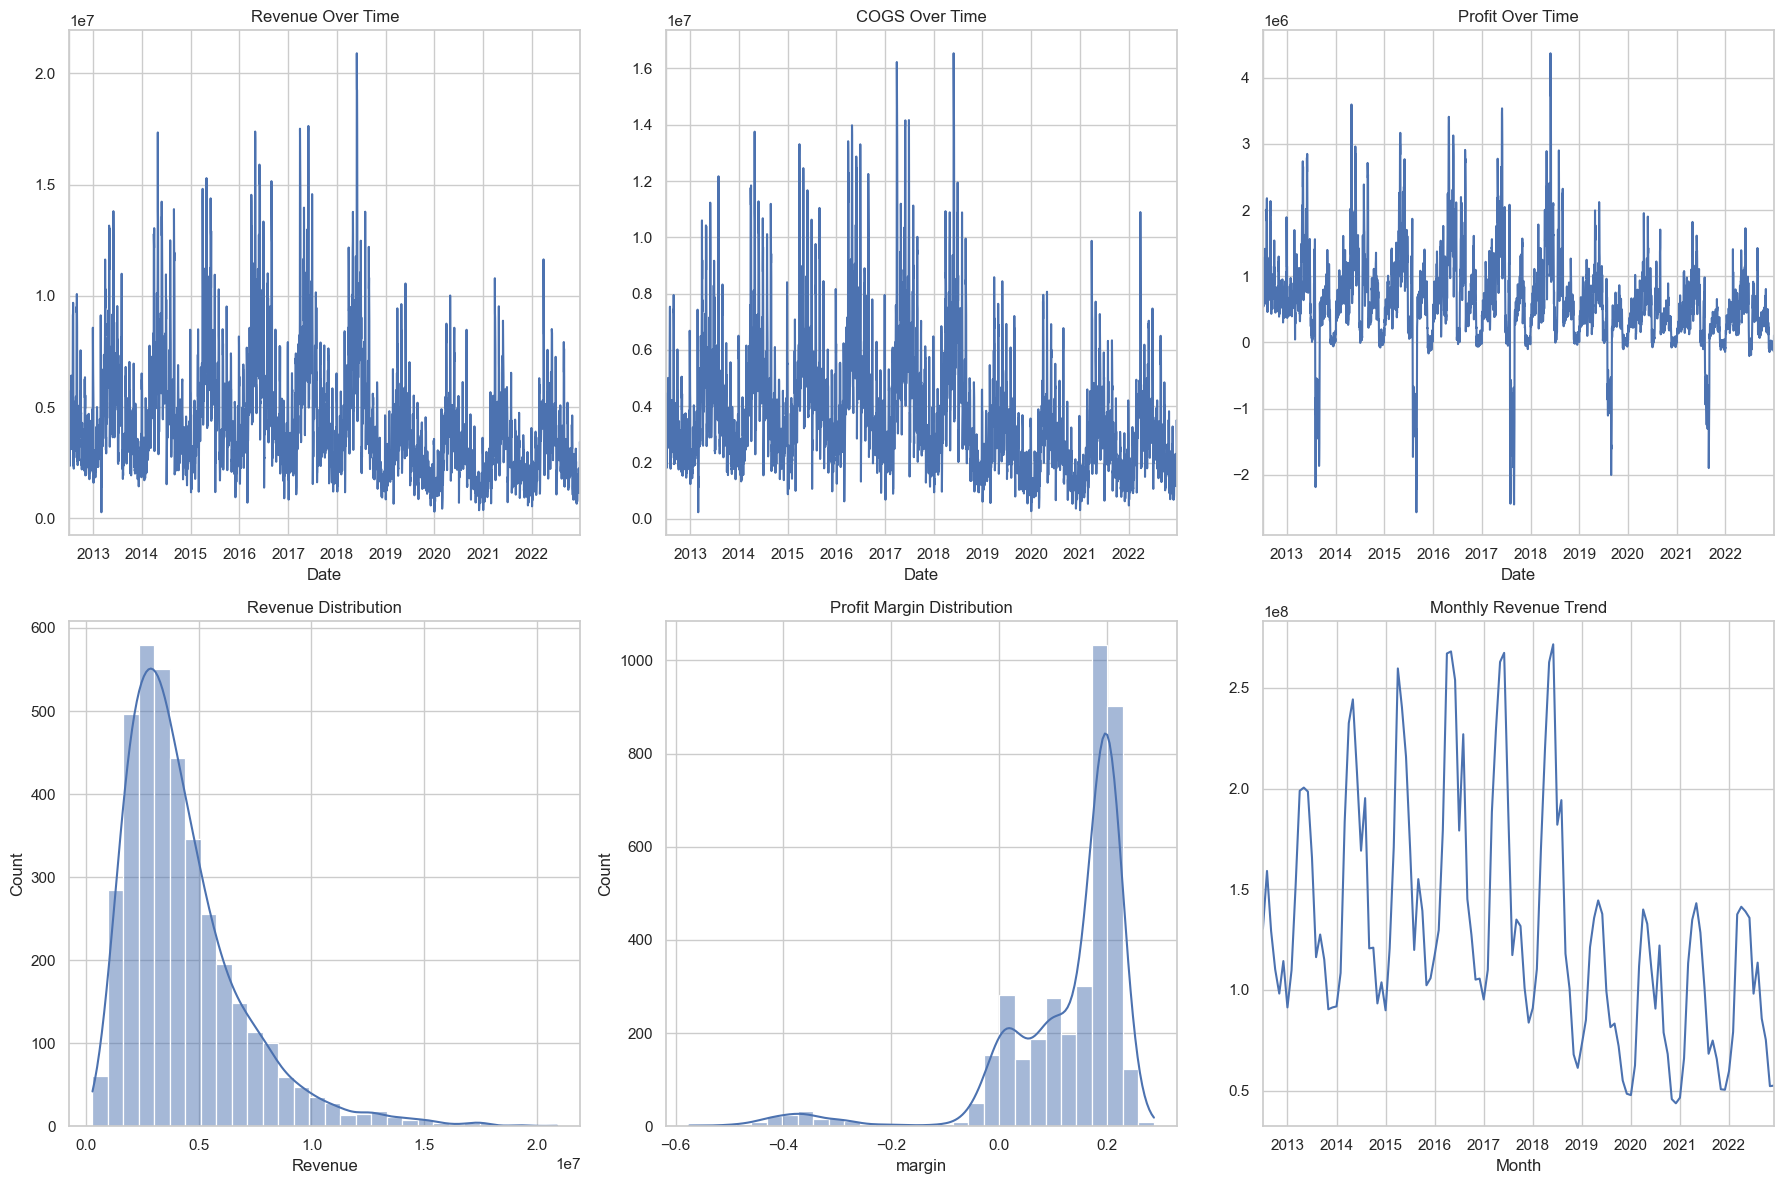


🔹 Negative revenue: 0
🔹 Negative COGS: 0
🔹 Revenue < COGS (negative profit): 382
🔹 Missing Date: 0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/sales.csv", parse_dates=['Date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate Date:", df['Date'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.to_period('M')

df['profit'] = df['Revenue'] - df['COGS']
df['margin'] = df['profit'] / df['Revenue']

# Visualization
plt.figure(figsize=(18, 12))

# 1. Revenue over time
plt.subplot(2, 3, 1)
df.set_index('Date')['Revenue'].plot()
plt.title("Revenue Over Time")

# 2. COGS over time
plt.subplot(2, 3, 2)
df.set_index('Date')['COGS'].plot()
plt.title("COGS Over Time")

# 3. Profit over time
plt.subplot(2, 3, 3)
df.set_index('Date')['profit'].plot()
plt.title("Profit Over Time")

# 4. Revenue distribution
plt.subplot(2, 3, 4)
sns.histplot(df['Revenue'], bins=30, kde=True)
plt.title("Revenue Distribution")

# 5. Profit margin distribution
plt.subplot(2, 3, 5)
sns.histplot(df['margin'], bins=30, kde=True)
plt.title("Profit Margin Distribution")

# 6. Monthly revenue trend
plt.subplot(2, 3, 6)
monthly_revenue = df.groupby('month')['Revenue'].sum()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Negative revenue:", (df['Revenue'] < 0).sum())
print("🔹 Negative COGS:", (df['COGS'] < 0).sum())
print("🔹 Revenue < COGS (negative profit):", (df['Revenue'] < df['COGS']).sum())
print("🔹 Missing Date:", df['Date'].isnull().sum())

# IV.Operational ( Vận hành )

## Inventory

🔹 Shape: (60247, 17)

🔹 Data types:
 snapshot_date        datetime64[ns]
product_id                    int64
stock_on_hand                 int64
units_received                int64
units_sold                    int64
stockout_days                 int64
days_of_supply              float64
fill_rate                   float64
stockout_flag                 int64
overstock_flag                int64
reorder_flag                  int64
sell_through_rate           float64
product_name                 object
category                     object
segment                      object
year                          int64
month                         int64
dtype: object

🔹 Missing values:
 snapshot_date        0
product_id           0
stock_on_hand        0
units_received       0
units_sold           0
stockout_days        0
days_of_supply       0
fill_rate            0
stockout_flag        0
overstock_flag       0
reorder_flag         0
sell_through_rate    0
product_name         0
category          

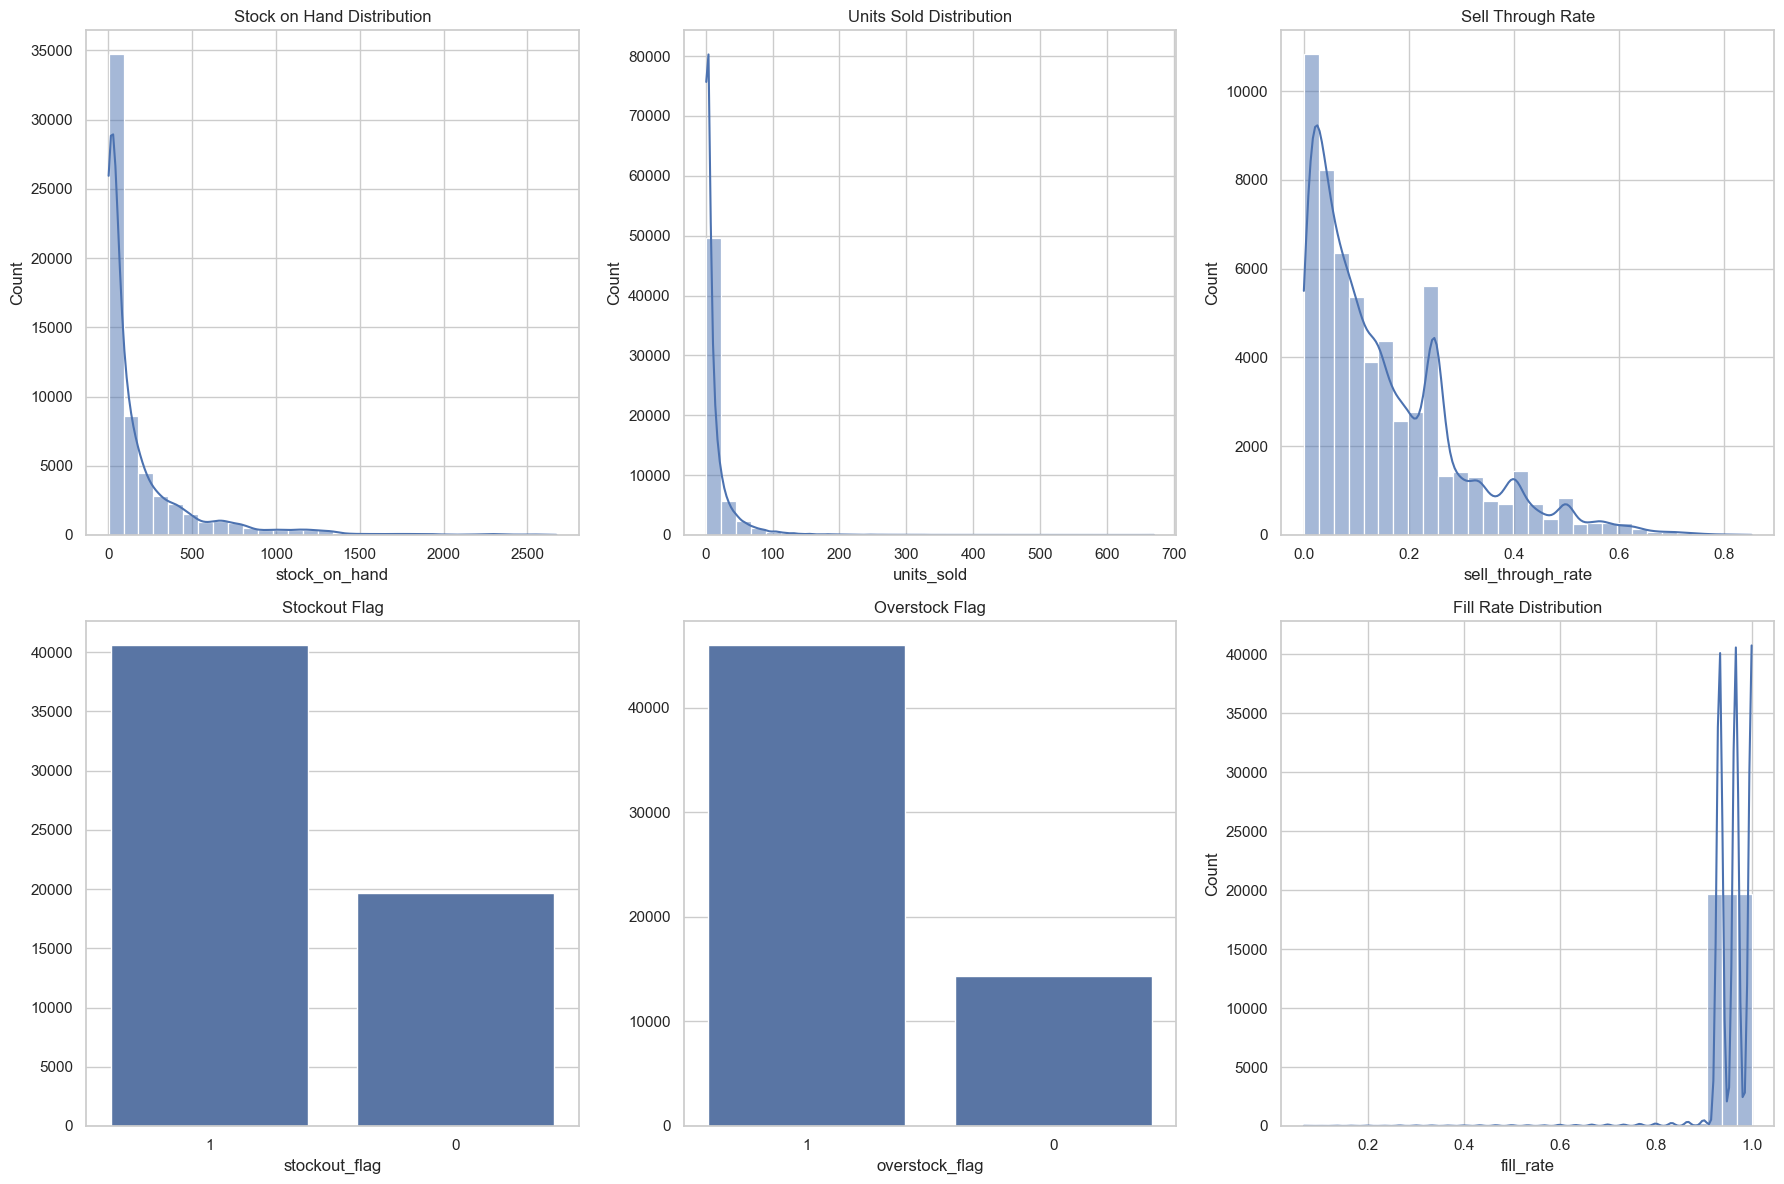

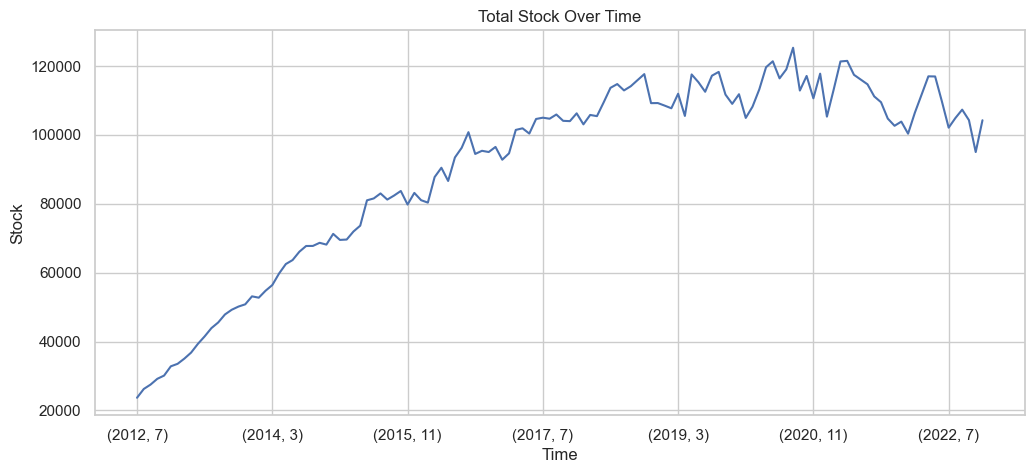


🔹 Negative stock: 0
🔹 Negative units_sold: 0
🔹 Invalid fill_rate (>1): 0
🔹 Invalid sell_through_rate (>1): 0


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/inventory.csv", parse_dates=['snapshot_date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate rows:", df.duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['inventory_turnover'] = df['units_sold'] / (df['stock_on_hand'] + 1)

# Visualization
plt.figure(figsize=(18, 12))

# 1. Stock on hand distribution
plt.subplot(2, 3, 1)
sns.histplot(df['stock_on_hand'], bins=30, kde=True)
plt.title("Stock on Hand Distribution")

# 2. Units sold distribution
plt.subplot(2, 3, 2)
sns.histplot(df['units_sold'], bins=30, kde=True)
plt.title("Units Sold Distribution")

# 3. Sell-through rate
plt.subplot(2, 3, 3)
sns.histplot(df['sell_through_rate'], bins=30, kde=True)
plt.title("Sell Through Rate")

# 4. Stockout flag
plt.subplot(2, 3, 4)
stockout_counts = df['stockout_flag'].value_counts()
sns.barplot(x=stockout_counts.index.astype(str), y=stockout_counts.values)
plt.title("Stockout Flag")

# 5. Overstock flag
plt.subplot(2, 3, 5)
overstock_counts = df['overstock_flag'].value_counts()
sns.barplot(x=overstock_counts.index.astype(str), y=overstock_counts.values)
plt.title("Overstock Flag")

# 6. Fill rate distribution
plt.subplot(2, 3, 6)
sns.histplot(df['fill_rate'], bins=30, kde=True)
plt.title("Fill Rate Distribution")

plt.tight_layout()
plt.show()

# =========================
# 📊 TIME SERIES
# =========================
plt.figure(figsize=(12, 5))
monthly_stock = df.groupby(['year', 'month'])['stock_on_hand'].sum()
monthly_stock.plot()
plt.title("Total Stock Over Time")
plt.xlabel("Time")
plt.ylabel("Stock")
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Negative stock:", (df['stock_on_hand'] < 0).sum())
print("🔹 Negative units_sold:", (df['units_sold'] < 0).sum())
print("🔹 Invalid fill_rate (>1):", (df['fill_rate'] > 1).sum())
print("🔹 Invalid sell_through_rate (>1):", (df['sell_through_rate'] > 1).sum())

## Web_traffic

🔹 Shape: (3652, 7)

🔹 Data types:
 date                        datetime64[ns]
sessions                             int64
unique_visitors                      int64
page_views                           int64
bounce_rate                        float64
avg_session_duration_sec           float64
traffic_source                      object
dtype: object

🔹 Missing values:
 date                        0
sessions                    0
unique_visitors             0
page_views                  0
bounce_rate                 0
avg_session_duration_sec    0
traffic_source              0
dtype: int64

🔹 Duplicate date: 0

🔹 Unique values:
 date                        3652
sessions                    3447
unique_visitors             3382
page_views                  3620
bounce_rate                  261
avg_session_duration_sec    1771
traffic_source                 6
dtype: int64


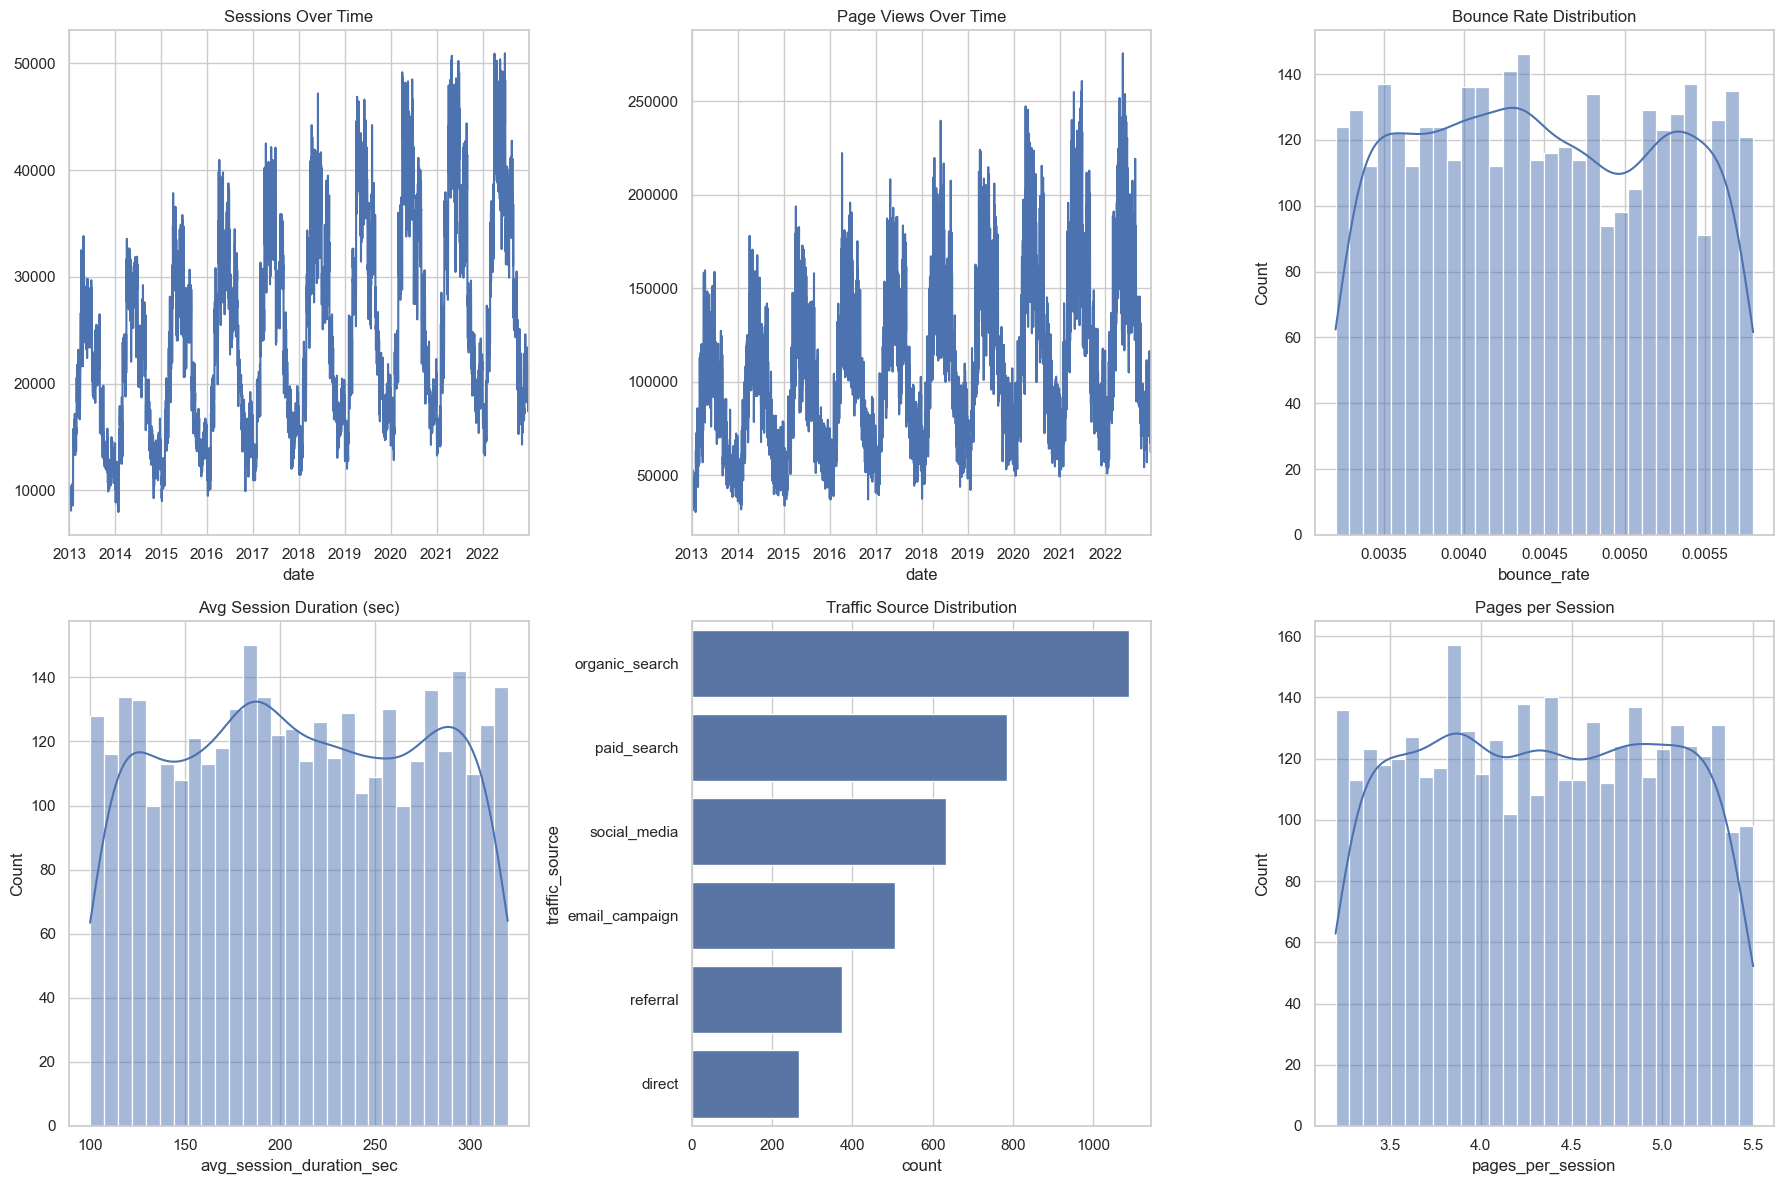

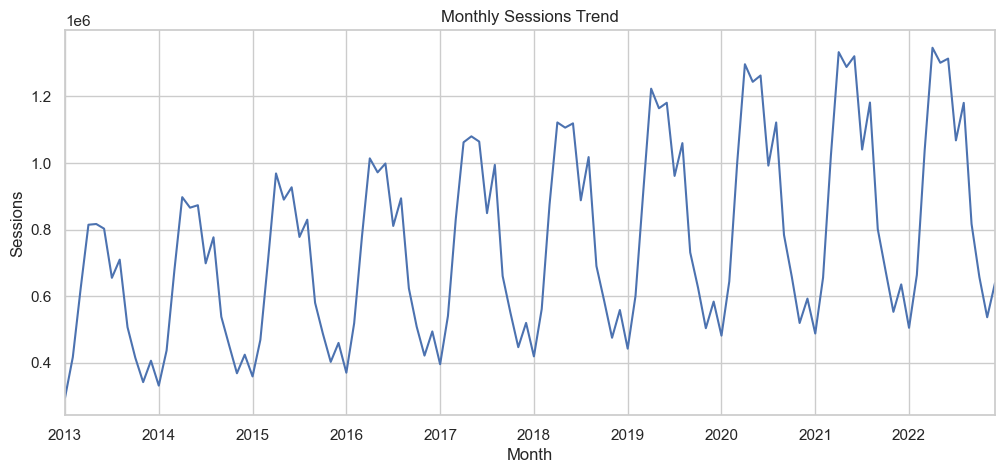


🔹 Negative sessions: 0
🔹 Negative page_views: 0
🔹 Invalid bounce_rate (>1): 0
🔹 Zero sessions: 0


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/web_traffic.csv", parse_dates=['date'])

# 📊 OVERVIEW
print("🔹 Shape:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())
print("\n🔹 Duplicate date:", df['date'].duplicated().sum())
print("\n🔹 Unique values:\n", df.nunique())

# 📅 FEATURE ENGINEERING
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.to_period('M')

df['pages_per_session'] = df['page_views'] / df['sessions']
df['visitor_ratio'] = df['unique_visitors'] / df['sessions']

# Visualization
plt.figure(figsize=(18, 12))

# 1. Sessions over time
plt.subplot(2, 3, 1)
df.set_index('date')['sessions'].plot()
plt.title("Sessions Over Time")

# 2. Page views over time
plt.subplot(2, 3, 2)
df.set_index('date')['page_views'].plot()
plt.title("Page Views Over Time")

# 3. Bounce rate distribution
plt.subplot(2, 3, 3)
sns.histplot(df['bounce_rate'], bins=30, kde=True)
plt.title("Bounce Rate Distribution")

# 4. Avg session duration
plt.subplot(2, 3, 4)
sns.histplot(df['avg_session_duration_sec'], bins=30, kde=True)
plt.title("Avg Session Duration (sec)")

# 5. Traffic source
plt.subplot(2, 3, 5)
sns.countplot(data=df, y='traffic_source', order=df['traffic_source'].value_counts().index)
plt.title("Traffic Source Distribution")

# 6. Pages per session
plt.subplot(2, 3, 6)
sns.histplot(df['pages_per_session'], bins=30, kde=True)
plt.title("Pages per Session")

plt.tight_layout()
plt.show()

# =========================
# 📊 TIME SERIES (AGG)
# =========================
plt.figure(figsize=(12, 5))
monthly_sessions = df.groupby('month')['sessions'].sum()
monthly_sessions.plot()
plt.title("Monthly Sessions Trend")
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.show()

# =========================
# ⚠️ DATA QUALITY CHECK
# =========================
print("\n🔹 Negative sessions:", (df['sessions'] < 0).sum())
print("🔹 Negative page_views:", (df['page_views'] < 0).sum())
print("🔹 Invalid bounce_rate (>1):", (df['bounce_rate'] > 1).sum())
print("🔹 Zero sessions:", (df['sessions'] == 0).sum())

# V. Overview

- Bộ dữ liệu sạch sẽ và đầy đủ với **không missing value** cũng như **không lỗi dữ liệu**